<a href="https://colab.research.google.com/github/ashadool26/Walmart_project/blob/main/Walmart_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data1 = pd.read_csv(r'/content/Walmart DataSet.csv')
data1.set_index('Date', inplace=True)
# There are about 45 different stores in this dataset. Lets select the any store id from 1-45
a= int(input("Enter the store id:"))
store = data1[data1.Store == a]
sales = pd.DataFrame(store.Weekly_Sales.groupby(store.index).sum())
sales.dtypes

Enter the store id:22


,0
Weekly_Sales,float64


In [ ]:
sales.head(20)

,Weekly_Sales
Date,
01-04-2011,951588.37
01-06-2012,1102857.37
01-07-2011,1077491.68
01-10-2010,905987.17
02-03-2012,974866.65
02-04-2010,1177340.99
02-07-2010,1120259.71
02-09-2011,912762.76
02-12-2011,1167621.14


In [ ]:
#remove date from index to change its dtype because it clearly isnt acceptable.
sales.reset_index(inplace = True)
#converting 'date' column to a datetime type
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)
# resetting date back to the index
sales.set_index('Date',inplace = True)

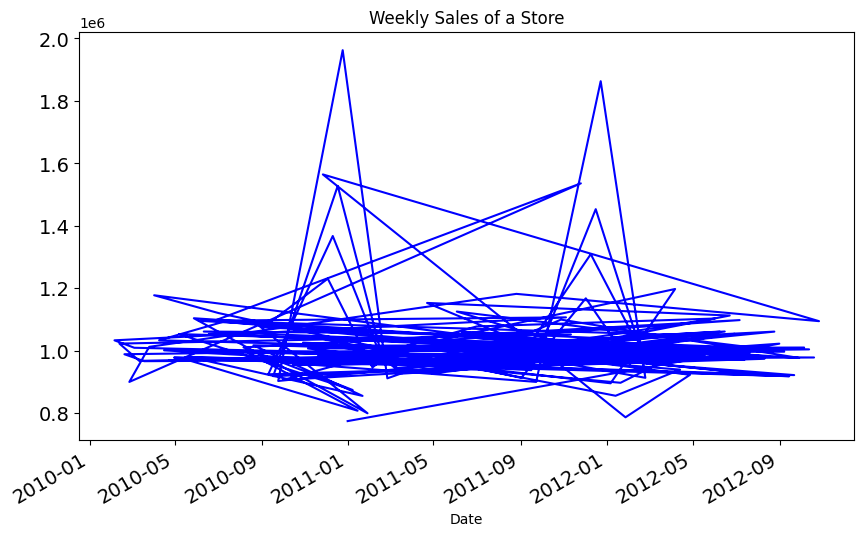

In [ ]:
sales.Weekly_Sales.plot(figsize=(10,6), title= 'Weekly Sales of a Store', fontsize=14, color = 'blue')
plt.show()

<Figure size 640x480 with 0 Axes>

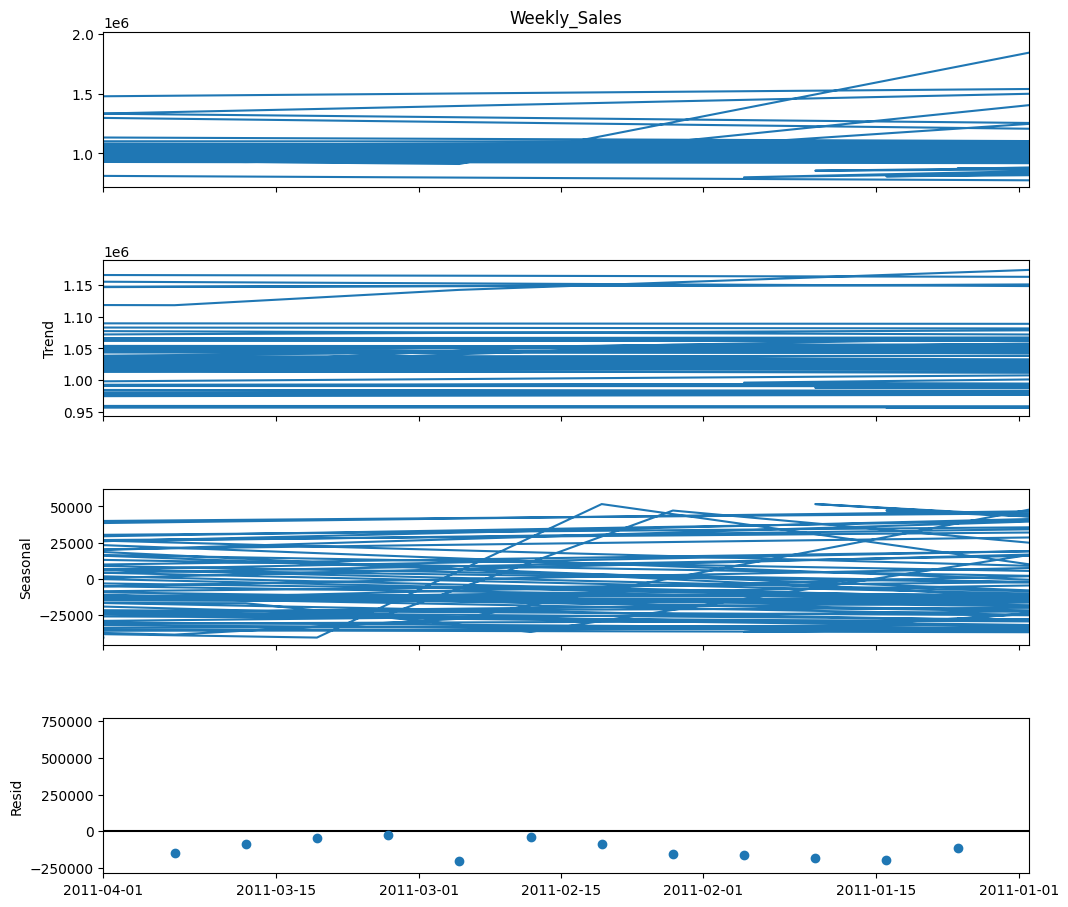

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(sales.Weekly_Sales, period=12)
fig = plt.figure()
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

In [ ]:
#lets compare the 2012 data of two stores
# Lets take store 5 data for analysis
store5 = data1[data1.Store == 5]
# there are about 45 different stores in this dataset.

sales5 = pd.DataFrame(store5.Weekly_Sales.groupby(store5.index).sum())
sales5.dtypes
# Grouped weekly sales by store 6

#remove date from index to change its dtype because it clearly isnt acceptable.
sales5.reset_index(inplace = True)

#converting 'date' column to a datetime type
sales5['Date'] = pd.to_datetime(sales5['Date'], dayfirst=True)
# resetting date back to the index
sales5.set_index('Date',inplace = True)

In [ ]:
y1=sales.Weekly_Sales
y2=sales5.Weekly_Sales

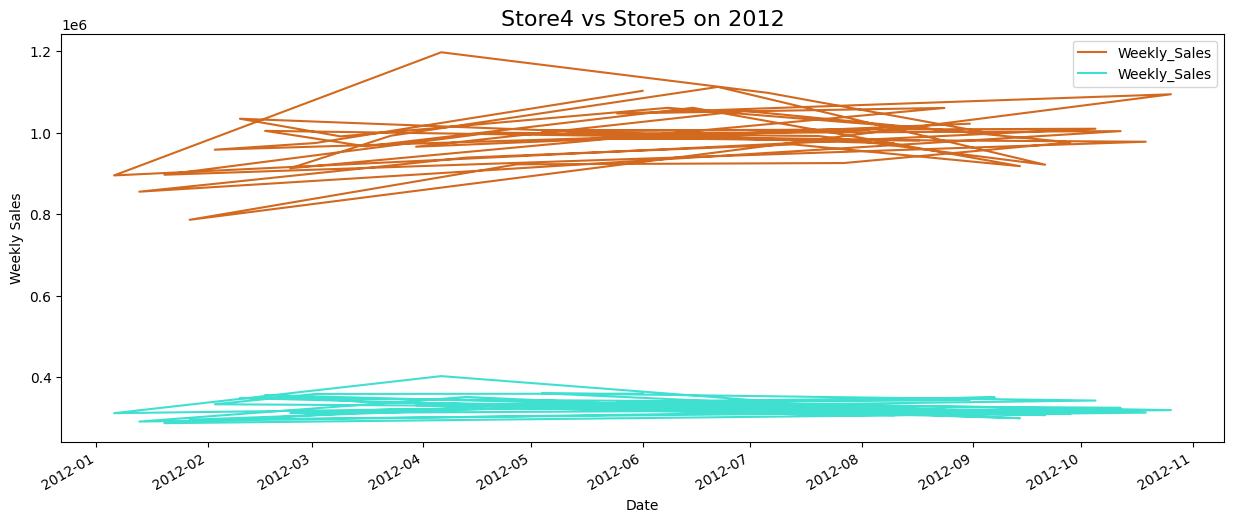

In [ ]:
y1['2012'].plot(figsize=(15, 6),legend=True, color = 'chocolate')
y2['2012'].plot(figsize=(15, 6), legend=True, color = 'turquoise')
plt.ylabel('Weekly Sales')
plt.title('Store4 vs Store5 on 2012', fontsize = '16')
plt.show()

Clearly we can see the irregularities

In [ ]:
#Define the p, d and q parameters to take any value between 0 and 2
p = d = q = range(0, 5)
import itertools
# Generate all different combinations of p, d and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, d and q triplets
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, d, q))]

In [ ]:
import statsmodels.api as sm

mod = sm.tsa.statespace.SARIMAX(y1,
                                order=(4, 4, 3),
                                seasonal_order=(1, 1, 0, 52),   #enforce_stationarity=False,
                                enforce_invertibility=False)

results = mod.fit()

print(results.summary().tables[1])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0811      0.318     -3.398      0.001      -1.705      -0.458
ar.L2         -0.9759      0.464     -2.102      0.036      -1.886      -0.066
ar.L3         -0.8252      0.383     -2.153      0.031      -1.576      -0.074
ar.L4         -0.6235      0.202     -3.080      0.002      -1.020      -0.227
ma.L1         -2.3849      0.334     -7.145      0.000      -3.039      -1.731
ma.L2          1.7956      0.682      2.632      0.008       0.458       3.133
ma.L3         -0.4083      0.357     -1.142      0.253      -1.109       0.292
ar.S.L52      -0.4664      0.179     -2.603      0.009      -0.817      -0.115
sigma2      1.142e+11   5.58e-12   2.05e+22      0.000    1.14e+11    1.14e+11


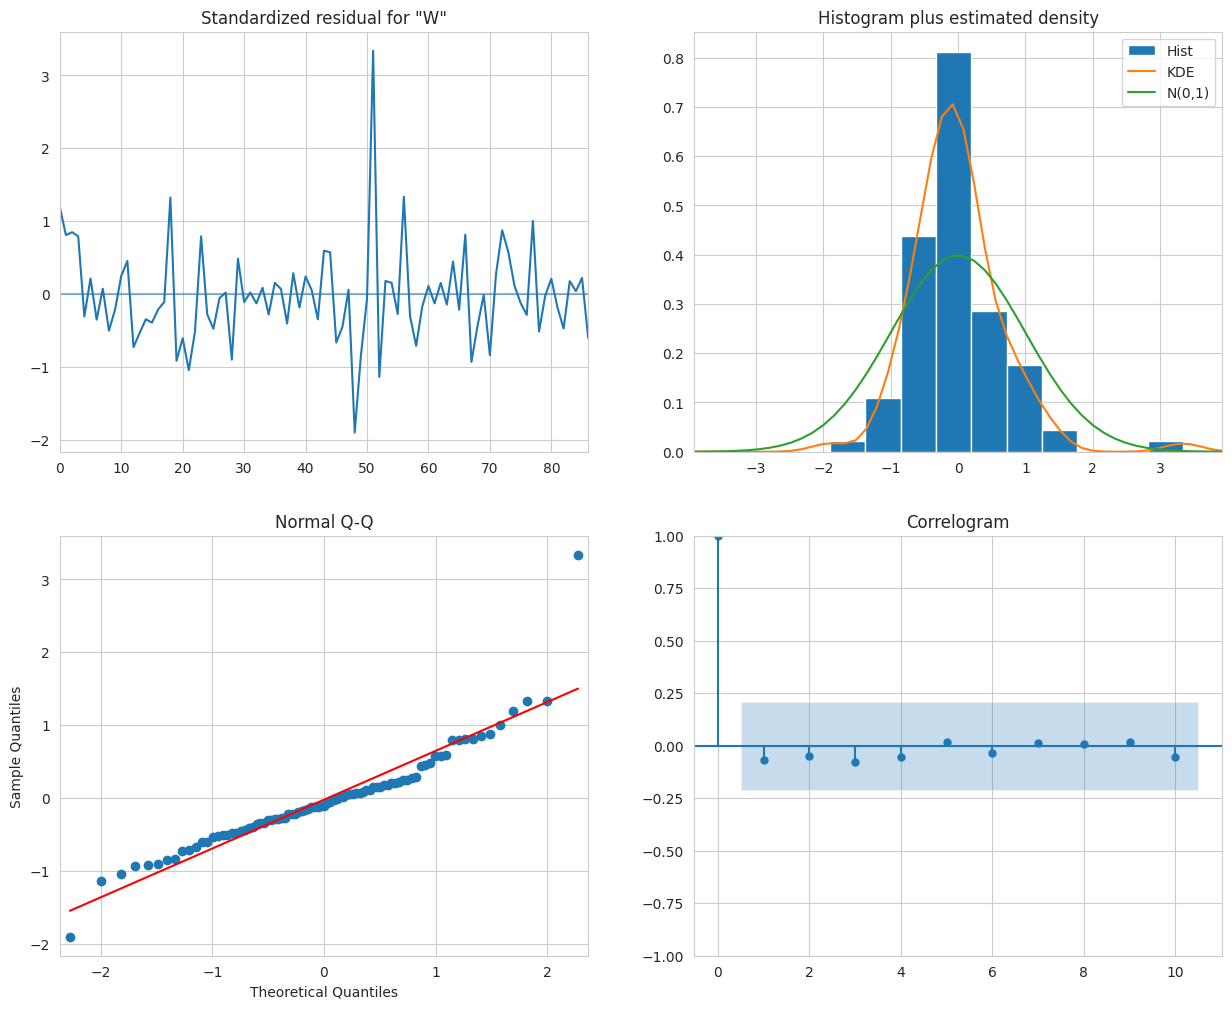

In [ ]:
import seaborn as sns

sns.set_style('whitegrid') # Changed from 'pastel' to a valid style
results.plot_diagnostics(figsize=(15, 12))
plt.show()

In [ ]:
pred = results.get_prediction(start=pd.to_datetime('2012-07-27'), dynamic=False)
pred_ci = pred.conf_int()

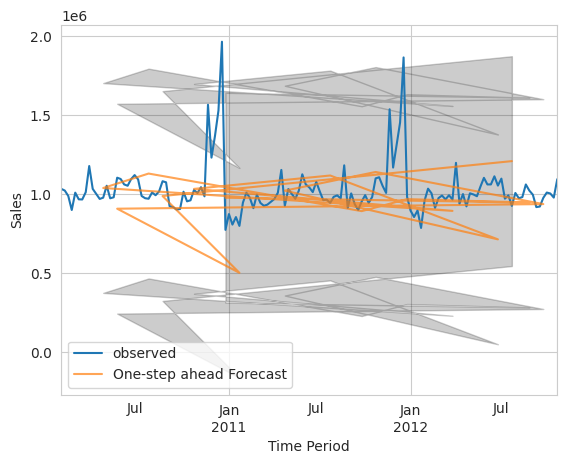

In [ ]:
y1 = y1.sort_index()
ax = y1['2010':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7)

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')
plt.legend()

plt.show()

In [ ]:
y_forecasted = pred.predicted_mean
y_truth = y1['2012-7-27':]

# Compute the mean square error
mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 29052083190.38


In [ ]:
pred_dynamic = results.get_prediction(start=pd.to_datetime('2012-7-27'), dynamic=True, full_results=True)
pred_dynamic_ci = pred_dynamic.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['full_results']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


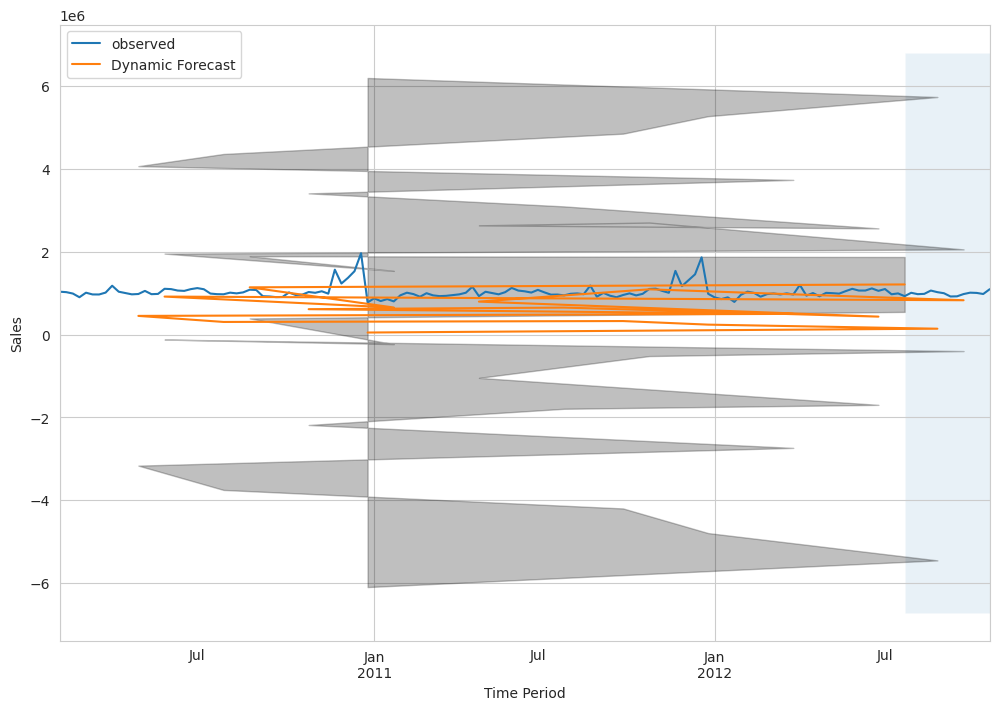

In [ ]:
ax = y1['2010':].plot(label='observed', figsize=(12, 8))
pred_dynamic.predicted_mean.plot(label='Dynamic Forecast', ax=ax)

ax.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='k', alpha=.25)

ax.fill_betweenx(ax.get_ylim(), pd.to_datetime('2012-7-26'), y1.index[-1],
                 alpha=.1, zorder=-1)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')

plt.legend()
plt.show()


In [ ]:
import numpy as np
# Extract the predicted and true values of our time series
y_forecasted = pred_dynamic.predicted_mean
print(y_forecasted)

Date
2012-07-27    1.208385e+06
2010-08-27    1.138835e+06
2011-01-28    6.517040e+05
2010-05-28    9.154286e+05
2012-09-28    8.271413e+05
2011-10-28    1.091188e+06
2011-04-29    7.941731e+05
2012-06-29    4.317034e+05
2011-07-29    6.498896e+05
2010-10-29    6.114631e+05
2012-03-30    4.974394e+05
2010-04-30    4.493713e+05
2010-07-30    3.032982e+05
2011-09-30    3.248220e+05
2011-12-30    2.385437e+05
2012-08-31    1.401991e+05
2010-12-31    4.804221e+04
Name: predicted_mean, dtype: float64


In [ ]:
y_truth = y1['2012-7-27':]

print(y_truth)

Date
2012-07-27     925731.21
2012-08-03    1007257.83
2012-08-10     973812.79
2012-08-17     981273.26
2012-08-24    1060906.75
2012-08-31    1022270.86
2012-09-07     996628.80
2012-09-14     918049.28
2012-09-21     921612.53
2012-09-28     976479.51
2012-10-05    1009887.36
2012-10-12    1004039.84
2012-10-19     978027.95
2012-10-26    1094422.69
Name: Weekly_Sales, dtype: float64


In [ ]:
# Compute the Root mean square error
rmse = np.sqrt(((y_forecasted - y_truth) ** 2).mean())
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 2)))

The Root Mean Squared Error of our forecasts is 541678.2


In [ ]:
Residual= y_forecasted - y_truth
print("Residual for Store1",np.abs(Residual).sum())

Residual for Store1 1314064.1210438008


In [ ]:
# Get forecast 12 weeks ahead in future
pred_uc = results.get_forecast(steps=12)

print(pred_uc)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# Get confidence intervals of forecasts
pred_ci = pred_uc.conf_int()

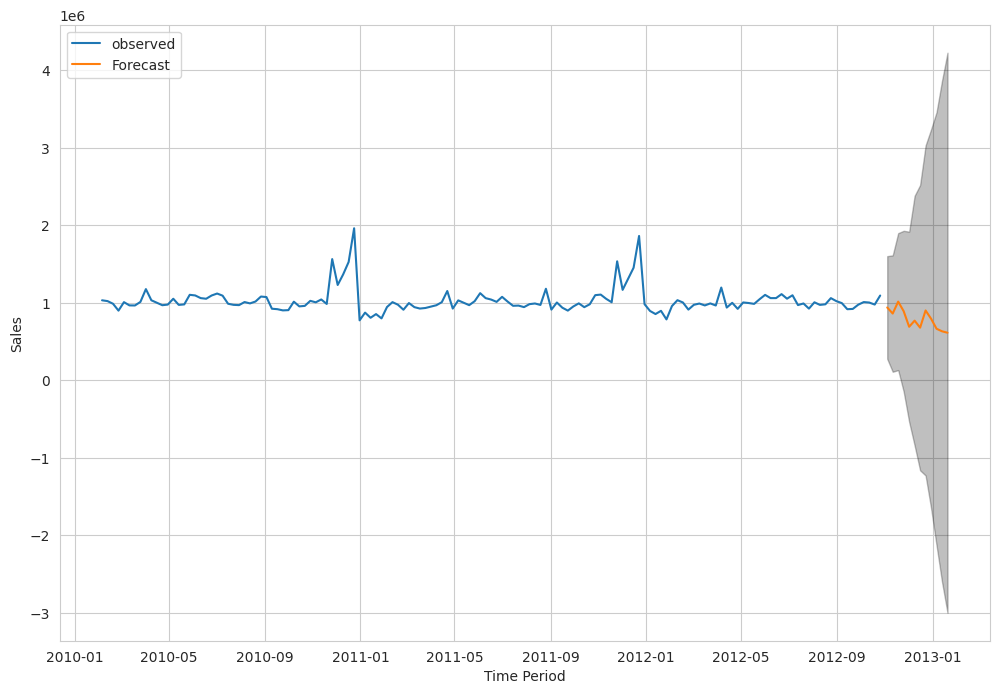

In [ ]:
# Get the last date from the observed series
last_date = y1.index[-1]

# Create a date range for the forecast (12 weeks, weekly frequency)
# Start date is one week after the last observed date
forecast_index = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=12, freq='W')

# Assign the new DatetimeIndex to the predicted mean and confidence intervals
# pred_uc.predicted_mean.index = forecast_index
# pred_ci.index = forecast_index

# Use matplotlib's plotting functions directly to avoid pandas' internal date axis handling issues
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(y1.index, y1.values, label='observed')
ax.plot(forecast_index, pred_uc.predicted_mean.values, label='Forecast')
ax.fill_between(forecast_index,
                pred_ci.iloc[:, 0], # pred_ci already has its index set to forecast_index
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')

ax.legend()
plt.show()